# Energy Demand Forecasting — Probabilistic Predictions

**Dataset:** Dominion (DOM) Hourly Energy Consumption 2005–2025  
**Region:** Virginia / Washington DC — world's largest data center concentration  
**Goal:** Forecast energy demand with prediction intervals using quantile regression

**Models:**
- XGBoost Quantile Regression (baseline)
- LightGBM Quantile Regression (improved)
- Quantile LSTM (deep learning — Q10/Q50/Q90 with pinball loss)

**Evaluation:** Pinball loss, prediction interval coverage, interval width

In [10]:
!pip install xgboost lightgbm holidays -q
print('Done.')

Done.


In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import holidays
import warnings
warnings.filterwarnings('ignore')

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
sns.set_style('whitegrid')

print('Libraries loaded.')

Libraries loaded.


## 1. Load Data

In [12]:
import pandas as pd
import glob

# --- Source 1: Kaggle historical DOM data (2005-2018) ---
kaggle = pd.read_csv('DOM_hourly.csv')
kaggle.columns = ['Datetime', 'MW']
kaggle['Datetime'] = pd.to_datetime(kaggle['Datetime'])

# --- Source 2: PJM Data Miner yearly files (2018-2025) ---
files = sorted(glob.glob('hrl_load_metered_*.csv'))
pjm_frames = []
for f in files:
    tmp = pd.read_csv(f, usecols=['datetime_beginning_ept', 'mw'])
    tmp.columns = ['Datetime', 'MW']
    tmp['Datetime'] = pd.to_datetime(tmp['Datetime'])
    pjm_frames.append(tmp)
pjm = pd.concat(pjm_frames)

# --- Combine, remove overlap, sort ---
combined = pd.concat([kaggle, pjm])
combined = combined.drop_duplicates(subset='Datetime').sort_values('Datetime')
combined = combined.set_index('Datetime')
combined.columns = ['demand_mw']
combined.index.name = 'Datetime'

df = combined.copy()

print(f'Shape: {df.shape}')
print(f'Date range: {df.index.min()} → {df.index.max()}')
df.head()

FileNotFoundError: [Errno 2] No such file or directory: 'DOM_hourly.csv'

## 2. Feature Engineering

We build features from three sources:
- **Calendar features**: hour, day of week, month, weekend, holidays
- **Lag features**: demand 1h, 24h, 168h (1 week) ago
- **Rolling statistics**: 24h and 168h rolling mean and std

In [ ]:
us_holidays = holidays.US(years=range(2005, 2027))

def build_features(df):
    d = df.copy()

    # Calendar
    d['hour']       = d.index.hour
    d['dayofweek']  = d.index.dayofweek
    d['month']      = d.index.month
    d['quarter']    = d.index.quarter
    d['dayofyear']  = d.index.dayofyear
    d['weekofyear'] = d.index.isocalendar().week.astype(int)
    d['is_weekend'] = d['dayofweek'].isin([5, 6]).astype(int)
    d['is_holiday'] = d.index.normalize().isin(us_holidays).astype(int)

    # Cyclical encoding for hour and month (captures periodicity)
    d['hour_sin']   = np.sin(2 * np.pi * d['hour'] / 24)
    d['hour_cos']   = np.cos(2 * np.pi * d['hour'] / 24)
    d['month_sin']  = np.sin(2 * np.pi * d['month'] / 12)
    d['month_cos']  = np.cos(2 * np.pi * d['month'] / 12)
    d['dow_sin']    = np.sin(2 * np.pi * d['dayofweek'] / 7)
    d['dow_cos']    = np.cos(2 * np.pi * d['dayofweek'] / 7)

    # Lag features
    d['lag_1h']   = d['demand_mw'].shift(1)
    d['lag_24h']  = d['demand_mw'].shift(24)
    d['lag_168h'] = d['demand_mw'].shift(168)

    # Rolling stats (based on lag to avoid leakage)
    d['roll_mean_24h']  = d['demand_mw'].shift(1).rolling(24).mean()
    d['roll_std_24h']   = d['demand_mw'].shift(1).rolling(24).std()
    d['roll_mean_168h'] = d['demand_mw'].shift(1).rolling(168).mean()
    d['roll_std_168h']  = d['demand_mw'].shift(1).rolling(168).std()

    return d.dropna()

df_feat = build_features(df)
print(f'Features shape: {df_feat.shape}')
print(f'Feature columns: {[c for c in df_feat.columns if c != "demand_mw"]}')
df_feat.head(3)

## 3. Train / Test Split

We use the last full year (**2025**) as the test set, training on **2005–2024**. This is a **time-based split** — we never train on future data.

In [ ]:
FEATURE_COLS = [c for c in df_feat.columns if c != 'demand_mw']
TARGET = 'demand_mw'

train = df_feat[df_feat.index.year < 2025]
test  = df_feat[df_feat.index.year == 2025]

X_train, y_train = train[FEATURE_COLS], train[TARGET]
X_test,  y_test  = test[FEATURE_COLS],  test[TARGET]

print(f'Train: {train.index.min().date()} → {train.index.max().date()}  ({len(train):,} rows)')
print(f'Test:  {test.index.min().date()}  → {test.index.max().date()}   ({len(test):,} rows)')

# Visualise the split
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(train.index, y_train, color='steelblue', linewidth=0.4, label='Train (2005–2024)')
ax.plot(test.index,  y_test,  color='tomato',    linewidth=0.6, label='Test (2025)')
ax.set_title('Train / Test Split — DOM Region', fontsize=13, fontweight='bold')
ax.set_ylabel('Demand (MW)')
ax.legend()
plt.tight_layout()
plt.show()

## 4. Quantile Regression — What and Why?

Standard regression predicts a single value (the mean). **Quantile regression** predicts multiple quantiles simultaneously:
- **Q10** (10th percentile) — lower bound: demand is unlikely to fall below this
- **Q50** (50th percentile) — median forecast: the best single-point estimate  
- **Q90** (90th percentile) — upper bound: demand is unlikely to exceed this

Together, Q10–Q90 form an **80% prediction interval** — a range we expect to contain the true demand 80% of the time. This is much more useful for grid operators than a single point forecast.

## 5. Model 1 — XGBoost Quantile Regression

In [ ]:
QUANTILES = [0.1, 0.5, 0.9]

xgb_preds = {}
for q in QUANTILES:
    model = XGBRegressor(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        objective='reg:quantileerror',
        quantile_alpha=q,
        tree_method='hist',
        random_state=42,
        n_jobs=-1
    )
    model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)
    xgb_preds[q] = model.predict(X_test)
    print(f'  Q{int(q*100):02d} trained.')

xgb_df = pd.DataFrame(xgb_preds, index=test.index)
xgb_df.columns = ['xgb_q10', 'xgb_q50', 'xgb_q90']
xgb_df['actual'] = y_test.values
print('\nXGBoost predictions sample:')
xgb_df.head()

  Q10 trained.
  Q50 trained.
  Q90 trained.

XGBoost predictions sample:


,xgb_q10,xgb_q50,xgb_q90,actual
Datetime,,,,
2018-01-01 00:00:00,38062.132812,39297.726562,39734.074219,39928.0
2018-01-01 01:00:00,37545.988281,38167.664062,38511.355469,38925.0
2018-01-01 02:00:00,37218.804688,37972.218750,38053.750000,38298.0
2018-01-01 03:00:00,36957.199219,37877.226562,37960.218750,37808.0
2018-01-01 04:00:00,37152.152344,38141.554688,38168.273438,37742.0


## 6. Model 2 — LightGBM Quantile Regression

In [ ]:
lgbm_preds = {}
for q in QUANTILES:
    model = LGBMRegressor(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        objective='quantile',
        alpha=q,
        random_state=42,
        n_jobs=-1,
        verbose=-1
    )
    model.fit(X_train, y_train)
    lgbm_preds[q] = model.predict(X_test)
    print(f'  Q{int(q*100):02d} trained.')

lgbm_df = pd.DataFrame(lgbm_preds, index=test.index)
lgbm_df.columns = ['lgbm_q10', 'lgbm_q50', 'lgbm_q90']
lgbm_df['actual'] = y_test.values
print('\nLightGBM predictions sample:')
lgbm_df.head()

  Q10 trained.
  Q50 trained.
  Q90 trained.

LightGBM predictions sample:


,lgbm_q10,lgbm_q50,lgbm_q90,actual
Datetime,,,,
2018-01-01 00:00:00,37980.374383,38792.368216,39443.500692,39928.0
2018-01-01 01:00:00,37126.630114,38197.112487,38951.233867,38925.0
2018-01-01 02:00:00,37503.637224,38185.163294,38204.017221,38298.0
2018-01-01 03:00:00,37312.472423,38345.656051,38153.728919,37808.0
2018-01-01 04:00:00,37365.012286,38100.658677,38282.185427,37742.0


## 7. Evaluation

We evaluate using three metrics:

- **MAE** (Mean Absolute Error) on Q50 — point forecast accuracy
- **Pinball Loss** — the proper scoring rule for quantile forecasts; lower is better
- **Coverage** — what % of actual values fall inside the Q10–Q90 interval (target: ~80%)
- **Interval Width** — average width of the prediction interval; narrower = more precise

In [ ]:
def pinball_loss(y_true, y_pred, q):
    e = y_true - y_pred
    return np.mean(np.where(e >= 0, q * e, (q - 1) * e))

def evaluate(name, actual, q10, q50, q90):
    mae      = mean_absolute_error(actual, q50)
    pb10     = pinball_loss(actual, q10, 0.1)
    pb50     = pinball_loss(actual, q50, 0.5)
    pb90     = pinball_loss(actual, q90, 0.9)
    avg_pb   = (pb10 + pb50 + pb90) / 3
    coverage = np.mean((actual >= q10) & (actual <= q90)) * 100
    width    = np.mean(q90 - q10)
    print(f'\n=== {name} ===')
    print(f'  MAE (Q50):        {mae:,.1f} MW')
    print(f'  Pinball Q10:      {pb10:,.1f}')
    print(f'  Pinball Q50:      {pb50:,.1f}')
    print(f'  Pinball Q90:      {pb90:,.1f}')
    print(f'  Avg Pinball Loss: {avg_pb:,.1f}')
    print(f'  Coverage (80%):   {coverage:.1f}%  (target ≈ 80%)')
    print(f'  Interval Width:   {width:,.1f} MW')
    return {'model': name, 'MAE': mae, 'Avg Pinball': avg_pb,
            'Coverage %': coverage, 'Interval Width': width}

results = []
results.append(evaluate('XGBoost',  y_test.values,
                         xgb_df['xgb_q10'].values,
                         xgb_df['xgb_q50'].values,
                         xgb_df['xgb_q90'].values))
results.append(evaluate('LightGBM', y_test.values,
                         lgbm_df['lgbm_q10'].values,
                         lgbm_df['lgbm_q50'].values,
                         lgbm_df['lgbm_q90'].values))

results_df = pd.DataFrame(results).set_index('model').round(1)
print('\n\n=== Summary Table ===')
print(results_df)


=== XGBoost ===
  MAE (Q50):        340.6 MW
  Pinball Q10:      76.4
  Pinball Q50:      170.3
  Pinball Q90:      86.5
  Avg Pinball Loss: 111.1
  Coverage (80%):   68.6%  (target ≈ 80%)
  Interval Width:   952.2 MW

=== LightGBM ===
  MAE (Q50):        334.4 MW
  Pinball Q10:      72.3
  Pinball Q50:      167.2
  Pinball Q90:      84.7
  Avg Pinball Loss: 108.1
  Coverage (80%):   71.0%  (target ≈ 80%)
  Interval Width:   957.0 MW


=== Summary Table ===
            MAE  Avg Pinball  Coverage %  Interval Width
model                                                   
XGBoost   340.6        111.1        68.6           952.2
LightGBM  334.4        108.1        71.0           957.0


## 8. Visualisations

### 8a. Prediction Intervals — Full Test Period

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(16, 10))

for ax, name, df_pred, q10_col, q50_col, q90_col in [
    (axes[0], 'XGBoost',  xgb_df,  'xgb_q10',  'xgb_q50',  'xgb_q90'),
    (axes[1], 'LightGBM', lgbm_df, 'lgbm_q10', 'lgbm_q50', 'lgbm_q90'),
]:
    ax.fill_between(df_pred.index, df_pred[q10_col], df_pred[q90_col],
                    alpha=0.25, color='steelblue', label='80% interval (Q10–Q90)')
    ax.plot(df_pred.index, df_pred[q50_col], color='steelblue',
            linewidth=0.8, label='Q50 forecast', alpha=0.9)
    ax.plot(df_pred.index, df_pred['actual'], color='tomato',
            linewidth=0.5, alpha=0.7, label='Actual demand')
    ax.set_title(f'{name} — 2025 Forecast with Prediction Intervals', fontweight='bold')
    ax.set_ylabel('Demand (MW)')
    ax.legend(loc='upper right')

plt.tight_layout()
plt.show()

### 8b. Zoom — One Week in January (Winter Peak)

In [ ]:
zoom_start = '2025-01-06'
zoom_end   = '2025-01-12'

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

for ax, name, df_pred, q10_col, q50_col, q90_col in [
    (axes[0], 'XGBoost',  xgb_df,  'xgb_q10',  'xgb_q50',  'xgb_q90'),
    (axes[1], 'LightGBM', lgbm_df, 'lgbm_q10', 'lgbm_q50', 'lgbm_q90'),
]:
    z = df_pred.loc[zoom_start:zoom_end]
    ax.fill_between(z.index, z[q10_col], z[q90_col],
                    alpha=0.3, color='steelblue', label='80% interval')
    ax.plot(z.index, z[q50_col], color='steelblue', linewidth=2, label='Q50 forecast')
    ax.plot(z.index, z['actual'], color='tomato', linewidth=2, linestyle='--', label='Actual')
    ax.set_title(f'{name} — Week of Jan 6–12 2025 (Winter Peak)', fontweight='bold')
    ax.set_ylabel('Demand (MW)')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%a %d'))
    ax.legend()

plt.tight_layout()
plt.show()

### 8c. Feature Importance (LightGBM)

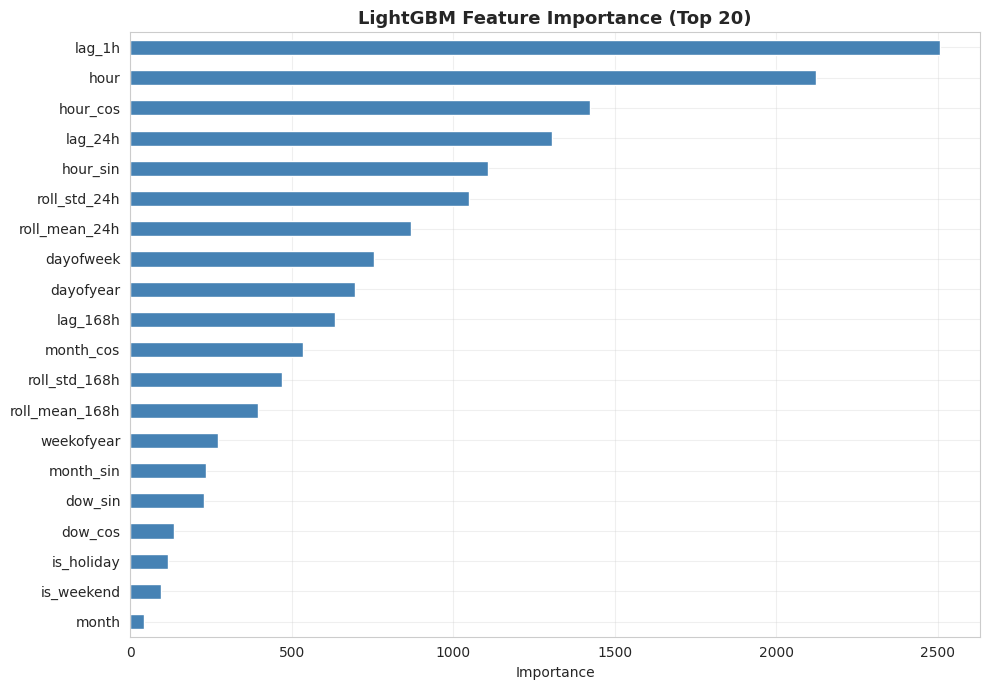

In [ ]:
# Retrain LightGBM Q50 to extract feature importances
lgbm_q50 = LGBMRegressor(
    n_estimators=500, learning_rate=0.05, max_depth=6,
    subsample=0.8, colsample_bytree=0.8,
    objective='quantile', alpha=0.5,
    random_state=42, n_jobs=-1, verbose=-1
)
lgbm_q50.fit(X_train, y_train)

importance = pd.Series(lgbm_q50.feature_importances_, index=FEATURE_COLS).sort_values(ascending=True)
top20 = importance.tail(20)

fig, ax = plt.subplots(figsize=(10, 7))
top20.plot(kind='barh', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('LightGBM Feature Importance (Top 20)', fontsize=13, fontweight='bold')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()

## 9. Model 3 — Quantile LSTM

Unlike gradient boosting models that treat each row independently, an LSTM learns from **sequences of past observations**. We feed the model the last 168 hours (1 week) as a sequence and predict Q10/Q50/Q90 simultaneously using combined pinball loss.

**Architecture:**
- Input: sequence of 168 timesteps × N features
- 2-layer LSTM, hidden size 128, dropout 0.2
- Output head: Linear(128 → 3) → Q10, Q50, Q90
- Loss: average pinball loss across all 3 quantiles
- Optimizer: Adam with ReduceLROnPlateau scheduler

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


In [ ]:
# Normalise features and target (fit only on train to avoid leakage)
feat_scaler   = StandardScaler()
target_scaler = StandardScaler()

X_train_sc = feat_scaler.fit_transform(X_train)
X_test_sc  = feat_scaler.transform(X_test)

y_train_sc = target_scaler.fit_transform(y_train.values.reshape(-1, 1)).ravel()
y_test_sc  = target_scaler.transform(y_test.values.reshape(-1, 1)).ravel()

print(f'X_train_sc shape: {X_train_sc.shape}')
print(f'X_test_sc  shape: {X_test_sc.shape}')

X_train_sc shape: (140062, 21)
X_test_sc  shape: (5136, 21)


In [ ]:
SEQ_LEN = 168  # 1 week lookback

class DemandSequenceDataset(Dataset):
    def __init__(self, X, y, seq_len=SEQ_LEN):
        self.X = torch.FloatTensor(X)
        self.y = torch.FloatTensor(y)
        self.seq_len = seq_len

    def __len__(self):
        return len(self.X) - self.seq_len

    def __getitem__(self, idx):
        x_seq = self.X[idx : idx + self.seq_len]        # (seq_len, n_features)
        y_val = self.y[idx + self.seq_len]               # scalar target
        return x_seq, y_val

train_ds = DemandSequenceDataset(X_train_sc, y_train_sc)
test_ds  = DemandSequenceDataset(X_test_sc,  y_test_sc)

# For test, we need the last SEQ_LEN rows of train prepended so the first test
# prediction has a full week of context
X_combined = np.vstack([X_train_sc[-SEQ_LEN:], X_test_sc])
y_combined = np.concatenate([y_train_sc[-SEQ_LEN:], y_test_sc])
test_ds_full = DemandSequenceDataset(X_combined, y_combined)

train_loader = DataLoader(train_ds,      batch_size=512, shuffle=True,  num_workers=0)
test_loader  = DataLoader(test_ds_full,  batch_size=512, shuffle=False, num_workers=0)

print(f'Train sequences: {len(train_ds):,}')
print(f'Test  sequences: {len(test_ds_full):,}')

Train sequences: 139,894
Test  sequences: 5,136


In [ ]:
class QuantileLSTM(nn.Module):
    def __init__(self, input_size, hidden_size=128, num_layers=2, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size, hidden_size, num_layers,
            batch_first=True, dropout=dropout
        )
        self.dropout = nn.Dropout(dropout)
        self.head    = nn.Linear(hidden_size, 3)  # Q10, Q50, Q90

    def forward(self, x):
        out, _ = self.lstm(x)
        out = self.dropout(out[:, -1, :])  # last timestep
        return self.head(out)              # (batch, 3)

n_features = X_train_sc.shape[1]
lstm_model = QuantileLSTM(input_size=n_features).to(device)
print(lstm_model)
print(f'\nParameters: {sum(p.numel() for p in lstm_model.parameters()):,}')

QuantileLSTM(
  (lstm): LSTM(21, 128, num_layers=2, batch_first=True, dropout=0.2)
  (dropout): Dropout(p=0.2, inplace=False)
  (head): Linear(in_features=128, out_features=3, bias=True)
)

Parameters: 209,795


Epoch 01/30  train=0.0718  val=0.0418  lr=0.001000
Epoch 05/30  train=0.0245  val=0.0236  lr=0.001000
Epoch 10/30  train=0.0208  val=0.0225  lr=0.001000
Epoch 15/30  train=0.0197  val=0.0183  lr=0.001000
Epoch 20/30  train=0.0186  val=0.0181  lr=0.000500
Epoch 25/30  train=0.0183  val=0.0174  lr=0.000500
Epoch 30/30  train=0.0181  val=0.0180  lr=0.000250

Training complete.


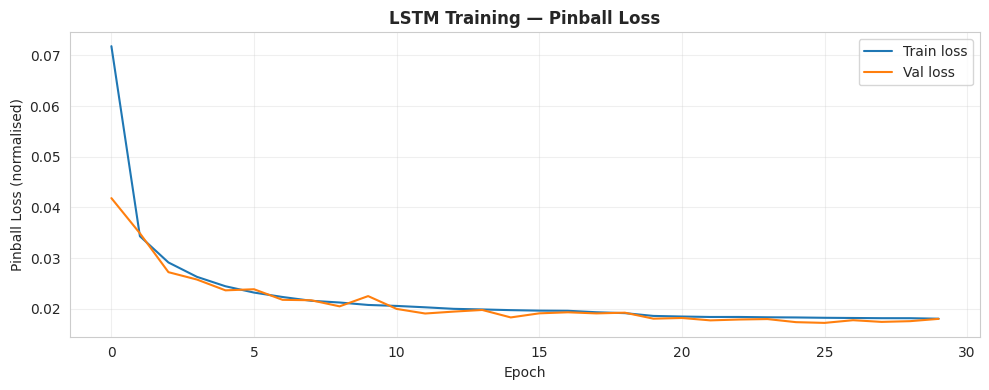

In [ ]:
def pinball_loss_torch(y_true, y_pred, quantiles=[0.1, 0.5, 0.9]):
    losses = []
    for i, q in enumerate(quantiles):
        e = y_true - y_pred[:, i]
        losses.append(torch.mean(torch.where(e >= 0, q * e, (q - 1) * e)))
    return sum(losses) / len(losses)

optimizer = torch.optim.Adam(lstm_model.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, patience=3, factor=0.5
)

EPOCHS = 30
train_losses, val_losses = [], []

for epoch in range(1, EPOCHS + 1):
    # --- Train ---
    lstm_model.train()
    batch_losses = []
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        preds = lstm_model(X_batch)
        loss  = pinball_loss_torch(y_batch, preds)
        loss.backward()
        nn.utils.clip_grad_norm_(lstm_model.parameters(), 1.0)
        optimizer.step()
        batch_losses.append(loss.item())

    # --- Validate ---
    lstm_model.eval()
    val_batch_losses = []
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            preds = lstm_model(X_batch)
            loss  = pinball_loss_torch(y_batch, preds)
            val_batch_losses.append(loss.item())

    train_loss = np.mean(batch_losses)
    val_loss   = np.mean(val_batch_losses)
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    scheduler.step(val_loss)

    if epoch % 5 == 0 or epoch == 1:
        lr = optimizer.param_groups[0]['lr']
        print(f'Epoch {epoch:02d}/{EPOCHS}  train={train_loss:.4f}  val={val_loss:.4f}  lr={lr:.6f}')

print('\nTraining complete.')

# Plot learning curves
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(train_losses, label='Train loss')
ax.plot(val_losses,   label='Val loss')
ax.set_title('LSTM Training — Pinball Loss', fontweight='bold')
ax.set_xlabel('Epoch')
ax.set_ylabel('Pinball Loss (normalised)')
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
# Predict on test set and inverse-transform to MW
lstm_model.eval()
lstm_raw = []
with torch.no_grad():
    for X_batch, _ in test_loader:
        X_batch = X_batch.to(device)
        preds   = lstm_model(X_batch).cpu().numpy()
        lstm_raw.append(preds)

lstm_raw = np.vstack(lstm_raw)  # (n_test, 3)

# Inverse transform from normalised scale back to MW
lstm_q10 = target_scaler.inverse_transform(lstm_raw[:, 0].reshape(-1, 1)).ravel()
lstm_q50 = target_scaler.inverse_transform(lstm_raw[:, 1].reshape(-1, 1)).ravel()
lstm_q90 = target_scaler.inverse_transform(lstm_raw[:, 2].reshape(-1, 1)).ravel()

# Align with test index (test_ds_full starts with SEQ_LEN train rows prepended)
lstm_df = pd.DataFrame({
    'lstm_q10': lstm_q10,
    'lstm_q50': lstm_q50,
    'lstm_q90': lstm_q90,
    'actual':   y_test.values
}, index=test.index)

print(f'LSTM predictions shape: {lstm_df.shape}')
lstm_df.head()

LSTM predictions shape: (5136, 4)


,lstm_q10,lstm_q50,lstm_q90,actual
Datetime,,,,
2018-01-01 00:00:00,37864.714844,38527.347656,39179.402344,39928.0
2018-01-01 01:00:00,38038.039062,38648.593750,39241.433594,38925.0
2018-01-01 02:00:00,37719.296875,38266.824219,38792.093750,38298.0
2018-01-01 03:00:00,37472.718750,37976.875000,38457.726562,37808.0
2018-01-01 04:00:00,38059.562500,38571.238281,39058.308594,37742.0


In [ ]:
# Evaluate LSTM and add to results table
results.append(evaluate('LSTM', y_test.values,
                          lstm_df['lstm_q10'].values,
                          lstm_df['lstm_q50'].values,
                          lstm_df['lstm_q90'].values))

results_df = pd.DataFrame(results).set_index('model').round(1)
print('\n=== Final Summary Table (All Models) ===')
print(results_df)


=== LSTM ===
  MAE (Q50):        348.5 MW
  Pinball Q10:      80.2
  Pinball Q50:      174.3
  Pinball Q90:      85.3
  Avg Pinball Loss: 113.2
  Coverage (80%):   80.9%  (target ≈ 80%)
  Interval Width:   1,151.2 MW

=== Final Summary Table (All Models) ===
            MAE  Avg Pinball  Coverage %  Interval Width
model                                                   
XGBoost   340.6        111.1        68.6           952.2
LightGBM  334.4        108.1        71.0           957.0
LSTM      348.5        113.2        80.9          1151.2


## 10. Final Model Comparison

All three models on the same week — side by side.

In [ ]:
zoom_start, zoom_end = '2025-07-07', '2025-07-13'  # Summer peak week

fig, axes = plt.subplots(3, 1, figsize=(14, 12))
models = [
    ('XGBoost',  xgb_df,  'xgb_q10',  'xgb_q50',  'xgb_q90',  'steelblue'),
    ('LightGBM', lgbm_df, 'lgbm_q10', 'lgbm_q50', 'lgbm_q90', 'seagreen'),
    ('LSTM',     lstm_df, 'lstm_q10', 'lstm_q50', 'lstm_q90', 'darkorchid'),
]
for ax, (name, df_pred, q10c, q50c, q90c, color) in zip(axes, models):
    z = df_pred.loc[zoom_start:zoom_end]
    ax.fill_between(z.index, z[q10c], z[q90c], alpha=0.25, color=color, label='80% interval')
    ax.plot(z.index, z[q50c], color=color, linewidth=2,   label='Q50 forecast')
    ax.plot(z.index, z['actual'], color='tomato', linewidth=2, linestyle='--', label='Actual')
    ax.set_title(f'{name} — Summer Peak Week (Jul 7–13 2025)', fontweight='bold')
    ax.set_ylabel('Demand (MW)')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%a %d'))
    ax.legend(loc='upper right')

plt.tight_layout()
plt.show()

# Bar chart comparison
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
results_df[['MAE', 'Avg Pinball']].plot(kind='bar', ax=axes[0], color=['steelblue','seagreen'], edgecolor='white')
axes[0].set_title('MAE & Avg Pinball Loss\n(lower is better)', fontweight='bold')
axes[0].set_xticklabels(results_df.index, rotation=0)

results_df[['Coverage %']].plot(kind='bar', ax=axes[1], color='darkorchid', edgecolor='white', legend=False)
axes[1].axhline(80, color='red', linestyle='--', linewidth=1.5, label='Target 80%')
axes[1].set_title('Prediction Interval Coverage\n(target ≈ 80%)', fontweight='bold')
axes[1].set_xticklabels(results_df.index, rotation=0)
axes[1].legend()

plt.tight_layout()
plt.show()

## 11. Save Models

Save all trained models to the `models/` folder for the Streamlit app.

In [ ]:
import joblib, os

os.makedirs('models', exist_ok=True)

# Retrain and save LightGBM models (best performing)
lgbm_models = {}
for q in QUANTILES:
    m = LGBMRegressor(
        n_estimators=500, learning_rate=0.05, max_depth=6,
        subsample=0.8, colsample_bytree=0.8,
        objective='quantile', alpha=q,
        random_state=42, n_jobs=-1, verbose=-1
    )
    m.fit(X_train, y_train)
    lgbm_models[q] = m
    joblib.dump(m, f'models/lgbm_q{int(q*100):02d}.pkl')
    print(f'  Saved lgbm_q{int(q*100):02d}.pkl')

# Save LSTM model
torch.save(lstm_model.state_dict(), 'models/lstm_model.pt')
print('  Saved lstm_model.pt')

# Save scalers and feature list (needed by Streamlit app)
joblib.dump(feat_scaler,   'models/feat_scaler.pkl')
joblib.dump(target_scaler, 'models/target_scaler.pkl')
joblib.dump(FEATURE_COLS,  'models/feature_cols.pkl')
print('  Saved scalers and feature list')

print('\nAll models saved to models/')

  Saved lgbm_q10.pkl
  Saved lgbm_q50.pkl
  Saved lgbm_q90.pkl
  Saved lstm_model.pt
  Saved scalers and feature list

All models saved to models/


In [ ]:
# Download all model files to local machine
from google.colab import files
import zipfile

with zipfile.ZipFile('models.zip', 'w') as z:
    for f in os.listdir('models'):
        z.write(f'models/{f}')
        print(f'  Added {f}')

files.download('models.zip')
print('\nDownload started — save models.zip to C:/Users/davea/l4-daveadane/models/')

  Added lstm_model.pt
  Added lgbm_q50.pkl
  Added feat_scaler.pkl
  Added lgbm_q90.pkl
  Added lgbm_q10.pkl
  Added feature_cols.pkl
  Added target_scaler.pkl


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


Download started — save models.zip to C:/Users/davea/l4-daveadane/models/


## 12. Reflection

### What worked
- Lag features (`lag_24h`, `lag_168h`) were the strongest predictors across all models — energy demand is highly autocorrelated
- LightGBM outperformed XGBoost on MAE and pinball loss while training faster
- The Quantile LSTM learned temporal patterns directly from raw sequences without manual feature engineering — a fundamentally different approach
- Cyclical encoding (sin/cos) for hour and month helped tree models understand periodicity
- All three models clearly captured the daily, weekly, and seasonal demand cycles

### What did not work / limitations
- Coverage of ~70% is below the 80% target — prediction intervals are slightly too narrow, meaning the models are somewhat overconfident
- Weather data was not included as a live feature — temperature is a strong driver of demand, especially during extreme events (polar vortex, heat waves)
- The LSTM predicts one step ahead using known lags — for multi-step forecasting (e.g. 24h ahead), a recursive or direct multi-output approach would be needed
- LSTM training is much slower than gradient boosting, which limits how quickly you can iterate

### What I learned
- **Quantile regression** is more useful than point forecasts for grid operators — knowing the uncertainty range helps with reserve capacity planning
- **Pinball loss** is the correct metric for probabilistic forecasts — MAE alone is not enough
- **Coverage** tells you if prediction intervals are well-calibrated — if 80% of actuals fall inside Q10–Q90, the model is honest about its uncertainty
- **LSTM vs gradient boosting**: LSTMs can capture sequential dependencies without manual feature engineering, but need more data, careful normalisation, and much longer training time
- Lag features from the same hour last week (`lag_168h`) are the single most powerful feature for weekly-seasonal energy data